# Appointment Behavior Functions

This notebook isolates the patient-behavior functions used in the first simulator and plots them directly, without running the appointment simulation itself.

The horizontal axis is always the original offered delay `\tau`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "appointment_simulation").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

for module_name in list(sys.modules):
    if module_name == "appointment_simulation" or module_name.startswith("appointment_simulation."):
        del sys.modules[module_name]

from IPython.display import display

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from appointment_simulation import (
    PatientClassConfig,
    behavior_profile_frame,
    green_savin_no_show,
    step_balking,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## Behavior presets

Use the active preset to switch between the default step-balking assumptions and a stricter balking alternative.

In [2]:
BEHAVIOR_PRESETS = {
    "baseline": {
        "horizon_days": 15,
        "lambda_1": 0.14,
        "lambda_2": 0.10,
        "balk_variant": "baseline",
        "notes": "Baseline step balking with source-aligned no-show curves.",
    },
    "strict_balking": {
        "horizon_days": 15,
        "lambda_1": 0.14,
        "lambda_2": 0.10,
        "balk_variant": "strict",
        "notes": "Earlier balk thresholds and higher balk levels.",
    },
}

ACTIVE_PRESET = "baseline"

pd.DataFrame(BEHAVIOR_PRESETS).T

,horizon_days,lambda_1,lambda_2,balk_variant,notes
baseline,15,0.14,0.1,baseline,Baseline step balking with source-aligned no-s...
strict_balking,15,0.14,0.1,strict,Earlier balk thresholds and higher balk levels.


In [3]:
def make_classes(lambda_1=0.14, lambda_2=0.10, balk_variant="baseline"):
    if balk_variant == "baseline":
        balk_1 = step_balking(threshold=4, low_delay_probability=0.05, high_delay_probability=0.60)
        balk_2 = step_balking(threshold=3, low_delay_probability=0.08, high_delay_probability=0.70)
    else:
        balk_1 = step_balking(threshold=2, low_delay_probability=0.10, high_delay_probability=0.85)
        balk_2 = step_balking(threshold=2, low_delay_probability=0.12, high_delay_probability=0.90)

    return [
        PatientClassConfig(
            class_id=1,
            label="class_1 (MRI-like)",
            arrival_rate=lambda_1,
            balk_probability=balk_1,
            cancel_probability=0.10,
            no_show_probability=green_savin_no_show(gamma_0=0.01, gamma_max=0.31, sensitivity=50.0),
        ),
        PatientClassConfig(
            class_id=2,
            label="class_2 (mental-health-like)",
            arrival_rate=lambda_2,
            balk_probability=balk_2,
            cancel_probability=0.06,
            no_show_probability=green_savin_no_show(gamma_0=0.15, gamma_max=0.51, sensitivity=9.0),
        ),
    ]


ACTIVE_BEHAVIOR_CONFIG = BEHAVIOR_PRESETS[ACTIVE_PRESET]
BASE_CLASSES = make_classes(
    lambda_1=ACTIVE_BEHAVIOR_CONFIG["lambda_1"],
    lambda_2=ACTIVE_BEHAVIOR_CONFIG["lambda_2"],
    balk_variant=ACTIVE_BEHAVIOR_CONFIG["balk_variant"],
)
BEHAVIOR_DF = behavior_profile_frame(BASE_CLASSES, horizon_days=ACTIVE_BEHAVIOR_CONFIG["horizon_days"])

BEHAVIOR_DF.head()

,class_id,label,tau_booked,balk_probability,no_show_probability,effective_cancel_probability
0,1,class_1 (MRI-like),0,0.05,0.010000,0.0
1,1,class_1 (MRI-like),1,0.05,0.015940,0.1
2,1,class_1 (MRI-like),2,0.05,0.021763,0.1
3,1,class_1 (MRI-like),3,0.05,0.027471,0.1
4,1,class_1 (MRI-like),4,0.60,0.033065,0.1


## Function tables

In [4]:
behavior_display_df = BEHAVIOR_DF.rename(columns={"tau_booked": "tau"})

display(
    behavior_display_df.pivot_table(
        index=["class_id", "label", "tau"],
        values=["balk_probability", "no_show_probability", "effective_cancel_probability"],
    ).reset_index().head(12)
)

behavior_display_df.tail(12)

,class_id,label,tau,balk_probability,effective_cancel_probability,no_show_probability
0,1,class_1 (MRI-like),0,0.05,0.0,0.010000
1,1,class_1 (MRI-like),1,0.05,0.1,0.015940
2,1,class_1 (MRI-like),2,0.05,0.1,0.021763
3,1,class_1 (MRI-like),3,0.05,0.1,0.027471
4,1,class_1 (MRI-like),4,0.60,0.1,0.033065
5,1,class_1 (MRI-like),5,0.60,0.1,0.038549
6,1,class_1 (MRI-like),6,0.60,0.1,0.043924
7,1,class_1 (MRI-like),7,0.60,0.1,0.049193
8,1,class_1 (MRI-like),8,0.60,0.1,0.054357
9,1,class_1 (MRI-like),9,0.60,0.1,0.059419


,class_id,label,tau,balk_probability,no_show_probability,effective_cancel_probability
18,2,class_2 (mental-health-like),3,0.7,0.252049,0.06
19,2,class_2 (mental-health-like),4,0.7,0.279175,0.06
20,2,class_2 (mental-health-like),5,0.7,0.303449,0.06
21,2,class_2 (mental-health-like),6,0.7,0.325170,0.06
22,2,class_2 (mental-health-like),7,0.7,0.344607,0.06
23,2,class_2 (mental-health-like),8,0.7,0.362000,0.06
24,2,class_2 (mental-health-like),9,0.7,0.377563,0.06
25,2,class_2 (mental-health-like),10,0.7,0.391491,0.06
26,2,class_2 (mental-health-like),11,0.7,0.403953,0.06
27,2,class_2 (mental-health-like),12,0.7,0.415105,0.06


## Function plots

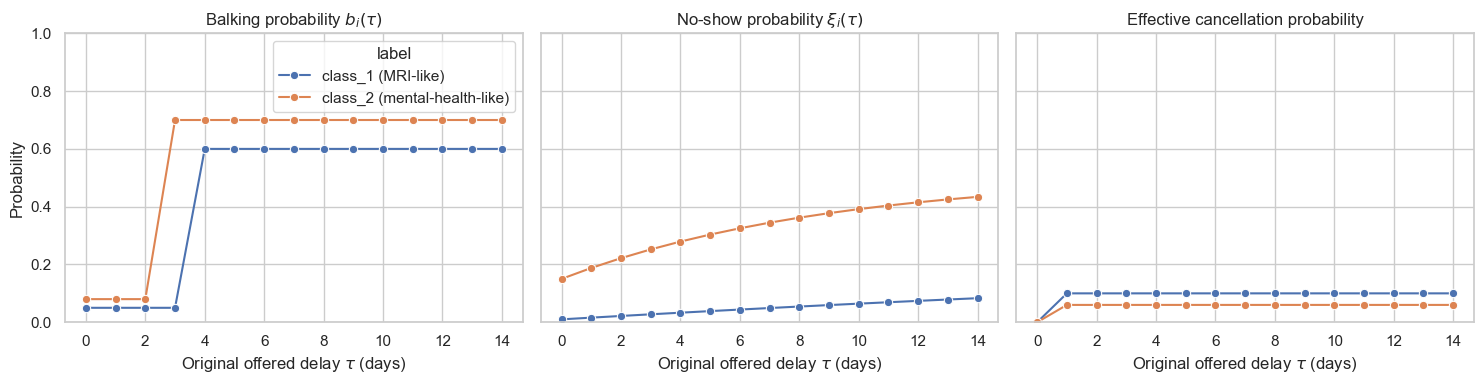

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

sns.lineplot(data=behavior_display_df, x="tau", y="balk_probability", hue="label", marker="o", ax=axes[0])
axes[0].set_title(r"Balking probability $b_i(\tau)$")
axes[0].set_xlabel(r"Original offered delay $\tau$ (days)")
axes[0].set_ylabel("Probability")

sns.lineplot(data=behavior_display_df, x="tau", y="no_show_probability", hue="label", marker="o", ax=axes[1], legend=False)
axes[1].set_title(r"No-show probability $\xi_i(\tau)$")
axes[1].set_xlabel(r"Original offered delay $\tau$ (days)")
axes[1].set_ylabel("")

sns.lineplot(data=behavior_display_df, x="tau", y="effective_cancel_probability", hue="label", marker="o", ax=axes[2], legend=False)
axes[2].set_title("Effective cancellation probability")
axes[2].set_xlabel(r"Original offered delay $\tau$ (days)")
axes[2].set_ylabel("")

for ax in axes:
    ax.set_ylim(0, 1)

plt.tight_layout()